<style>
    body, p, h1, h2, h3, li, span, div {
        font-family: 'Times New Roman', Times, serif !important;
    }
    ul ul, li li {
        list-style-type: none !important;
    }
    ul ul li::before, li li::before {
        content: "- " !important;
        display: inline-block;
        width: 1.2em;
        margin-left: -1.2em;
    }
    pre, code, .jp-OutputArea-output {
        font-family: Consolas, "Courier New", monospace !important;
    }
</style>

<br>

<div style="text-align: center;">
    <span style="font-size: 24px;">3_2_5_Descriptores_textura</span><br><br>
    <span>Julio 14, 2026</span><br><br><br>
    <img src="img/logoitqv1.jpg" width="450">
</div>

*Christian Villegas*

Link del repositorio: https://github.com/christian7villegas/Introducci-nPython

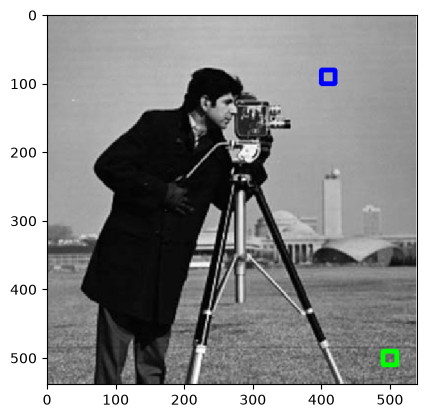

In [2]:
# En primer lugar, obtenemos la máscara de la imagen original mediante la umbralización con Otsu
import matplotlib.pyplot as plt
import cv2
import numpy as np
img = cv2.imread('images/photographer.png')
window = cv2.rectangle(img.copy(), (400,80), (420,100), (0, 0, 255), 5)
window = cv2.rectangle(window, (490,490), (510,510), (0, 255, 0), 5)
plt.imshow(window, cmap='gray')
plt.show()

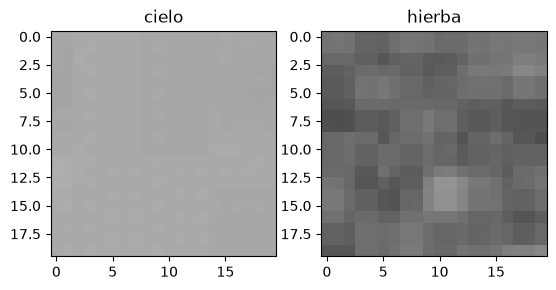

In [3]:
# Seleccionamos una región del cielo y una de la hierba
cielo = img[80:100, 400:420]
hierba = img[490:510, 490:510]
fig, ax = plt.subplots(1,2)
ax[0].imshow(cielo, cmap='gray')
ax[0].set_title('cielo')
ax[1].imshow(hierba, cmap='gray')
ax[1].set_title('hierba')
plt.show()


## 0.0.1 MATRIZ DE COOCURRENCIA


In [7]:
# MATRIZ DE COOCURRENCIA (Gray-Level Cooccurence Matrix - GLCM)
from tabulate import tabulate
from skimage.feature import graycomatrix, graycoprops

headers = ['', 'cielo', 'hierba']
CN, DIS, H, ASM, E, COR = ['contraste'], ['disimilitud'], ['homogeneidad'], ['ASM'], ['Energía'], ['Correlación']
patches = []
patches.append(cielo)
patches.append(hierba)

for i in range(len(patches)):
    image = cv2.cvtColor(patches[i], cv2.COLOR_BGR2GRAY)
    
    # Aplicamos la corrección de ortografía a "graycomatrix"
    GLCM = graycomatrix(image, distances=[5], angles=[0], levels=256, symmetric=True, normed=True)
    
    # Aplicamos la corrección a "graycoprops" en todos los cálculos
    CN.append(graycoprops(GLCM, 'contrast')[0,0])
    DIS.append(graycoprops(GLCM, 'dissimilarity')[0,0])
    H.append(graycoprops(GLCM, 'homogeneity')[0,0])
    ASM.append(graycoprops(GLCM, 'ASM')[0,0])
    E.append(graycoprops(GLCM, 'energy')[0,0])
    COR.append(graycoprops(GLCM, 'correlation')[0,0])

my_data = [tuple(CN), tuple(DIS), tuple(H), tuple(ASM), tuple(E), tuple(COR)]
print(tabulate(my_data, headers=headers))

                 cielo        hierba
------------  --------  ------------
contraste     3.68      333.393
disimilitud   1.4        13.8533
homogeneidad  0.512471    0.0921279
ASM           0.142717    0.00510556
Energía       0.377779    0.0714532
Correlación   0.190521   -0.0705127


## 0.0.2 Scale-Invariant Feature Transform


(1672, 128)


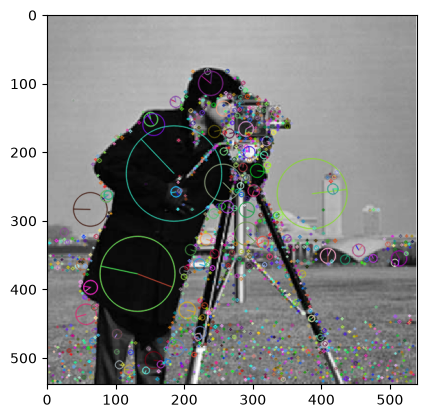

In [8]:
# SIFT algorithm
img = cv2.imread('images/photographer.png')
# Definición del algoritmo
sift = cv2.SIFT_create()
# Identificamos los puntos de interés
kp = sift.detect(img, None)
# Extraemos el descriptor para obtener el fingreprint
kp, des = sift.compute(img, kp)
print(np.shape(des))
# print(des) # Matriz donde las filas son los keypoints y las columnas las características de dichos puntos clave
# Visualizamos los puntos de interés
img=cv2.drawKeypoints(img, kp, img, flags=cv2.DRAW_MATCHES_FLAGS_DRAW_RICH_KEYPOINTS)
plt.imshow(img)
plt.show()


## 0.0.3 Histogram of Oriented Gradients


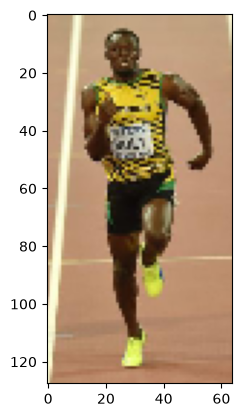

In [10]:
# HISTOGRAM OF ORIENTED GRADIENTS
# En primer lugar, obtenemos la máscara de la imagen original mediante la umbralización con Otsu
from skimage import io
img = io.imread('images/pedestrian.jpg')
img = np.float32(img/255)
crop = img[75:550,475:700]
crop = cv2.resize(crop, (64, 128))
plt.imshow(crop, cmap='gray')
plt.show()


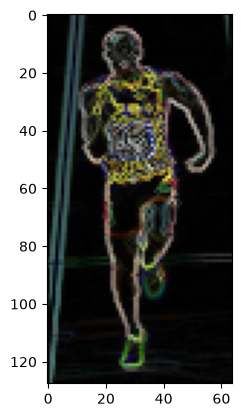

In [11]:
# Calculamos el gradiente con el kernel de Sobel
crop = np.float32(crop)
gx = cv2.Sobel(crop, cv2.CV_32F, 1, 0, ksize=1)
gy = cv2.Sobel(crop, cv2.CV_32F, 0, 1, ksize=1)
# Calculamos la magnitud y la dirección del gradiente
mag, angle = cv2.cartToPolar(gx, gy, angleInDegrees=True)
# Visualizamos la imagen obtenida en la magnitud del gradiente
mag = mag/np.max(mag)
plt.imshow(mag, cmap='gray')
plt.show()

In [14]:
# Cálculo del desriptor: Histogram of Oriented Gradients
from skimage.feature import hog

H = hog(crop, orientations=9, pixels_per_cell=(8, 8), cells_per_block=(2, 2), transform_sqrt=True, block_norm="L1", channel_axis=-1)

np.shape(H)

(3780,)

## 0.0.4 Local Binary Patterns


In [16]:
# LOCAL BINARY PATTERNS (LBP)
from skimage.feature import local_binary_pattern
img = cv2.imread('images/photographer.png')
# Definimos los parámetros iniciales
R = 1 # Radio
P = 8*R # Número de píxeles vecinos
epsilon = 1e-7 # Para normalizar el histograma
# Extraemos la imagen LBP
img_gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)
lbp_image = local_binary_pattern(img_gray, P, R, method='uniform')
a,b = np.unique(lbp_image, return_counts=True)
# Calculamos el histograma
lbp_image = np.uint8(lbp_image)
hist = cv2.calcHist([lbp_image.ravel()], [0], None, [P+2], [0, P+2])
# Normalizamos el histograma
hist = hist.astype("float")
hist /= (hist.sum() + epsilon)

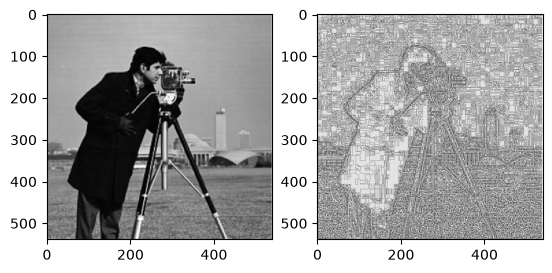

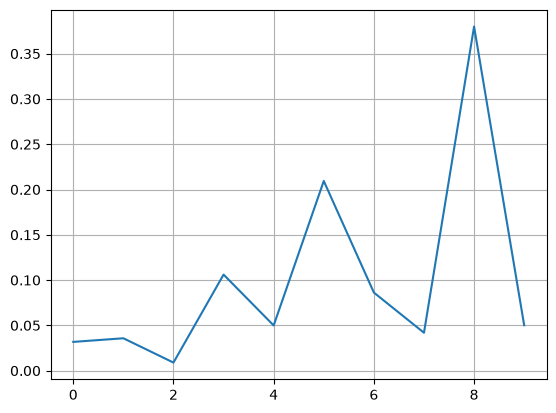

In [17]:
# Los P+2=10 bins del histograma serán los 10 atributos que nos permitirán caracterizar una imagen
# Visualizamos la imagen LBP
figs, ax = plt.subplots(1,2)
ax[0].imshow(img, cmap='gray')
ax[1].imshow(lbp_image, cmap='gray')
plt.show()
# Visualizamos el histograma
plt.plot(hist)
plt.grid(True)
plt.show()
